# This code is Modified from the example code from N2V github repo 
Check https://github.com/juglab/n2v/tree/main for more details

__Note:__ This notebook expects a trained model and will only work if you have executed the `01_training.ipynb` beforehand.

In [1]:
# We import all our dependencies.
from n2v.models import N2V
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread, imsave
from csbdeep.io import save_tiff_imagej_compatible

2026-05-28 16:59:37.089640: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 16:59:37.163259: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 16:59:37.166229: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-28 16:59:37.166236: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

## Load the Network

In [57]:
# A previously trained model is loaded by creating a new N2V-object without providing a 'config'.  
model_name = 'n2v_2D_copper_without_preprocessing'
basedir = 'models'
model = N2V(config=None, name=model_name, basedir=basedir)

Loading network weights from 'weights_best.weights.h5'.


In [51]:
# In case you do not want to load the weights that lead to lowest validation loss during 
# training but the latest computed weights, you can execute the following line:

# model.load_weights('weights_last.h5')

## Prediction
Here we will simply use the same image as during training and denoise it using our network.

In [66]:
# We read the image we want to process and get rid of the Alpha channel.
# img = imread('cropped_copper/noisy/image_copper_x0_y0.png')
# img = imread('cropped_copper/Cu(111)_0122.sxm_Z_sub_forward_01.jpg')
import cv2

# img = cv2.imread('cropped_copper/Cu(111)_0122.sxm_Z_sub_forward_01.jpg', cv2.IMREAD_GRAYSCALE)
img = imread('cropped_copper/noisy/image_copper_x40_y40.png')

# Here we process the image.
pred = model.predict(img, axes='YX')

1/1 [==============================] - 0s 342ms/step


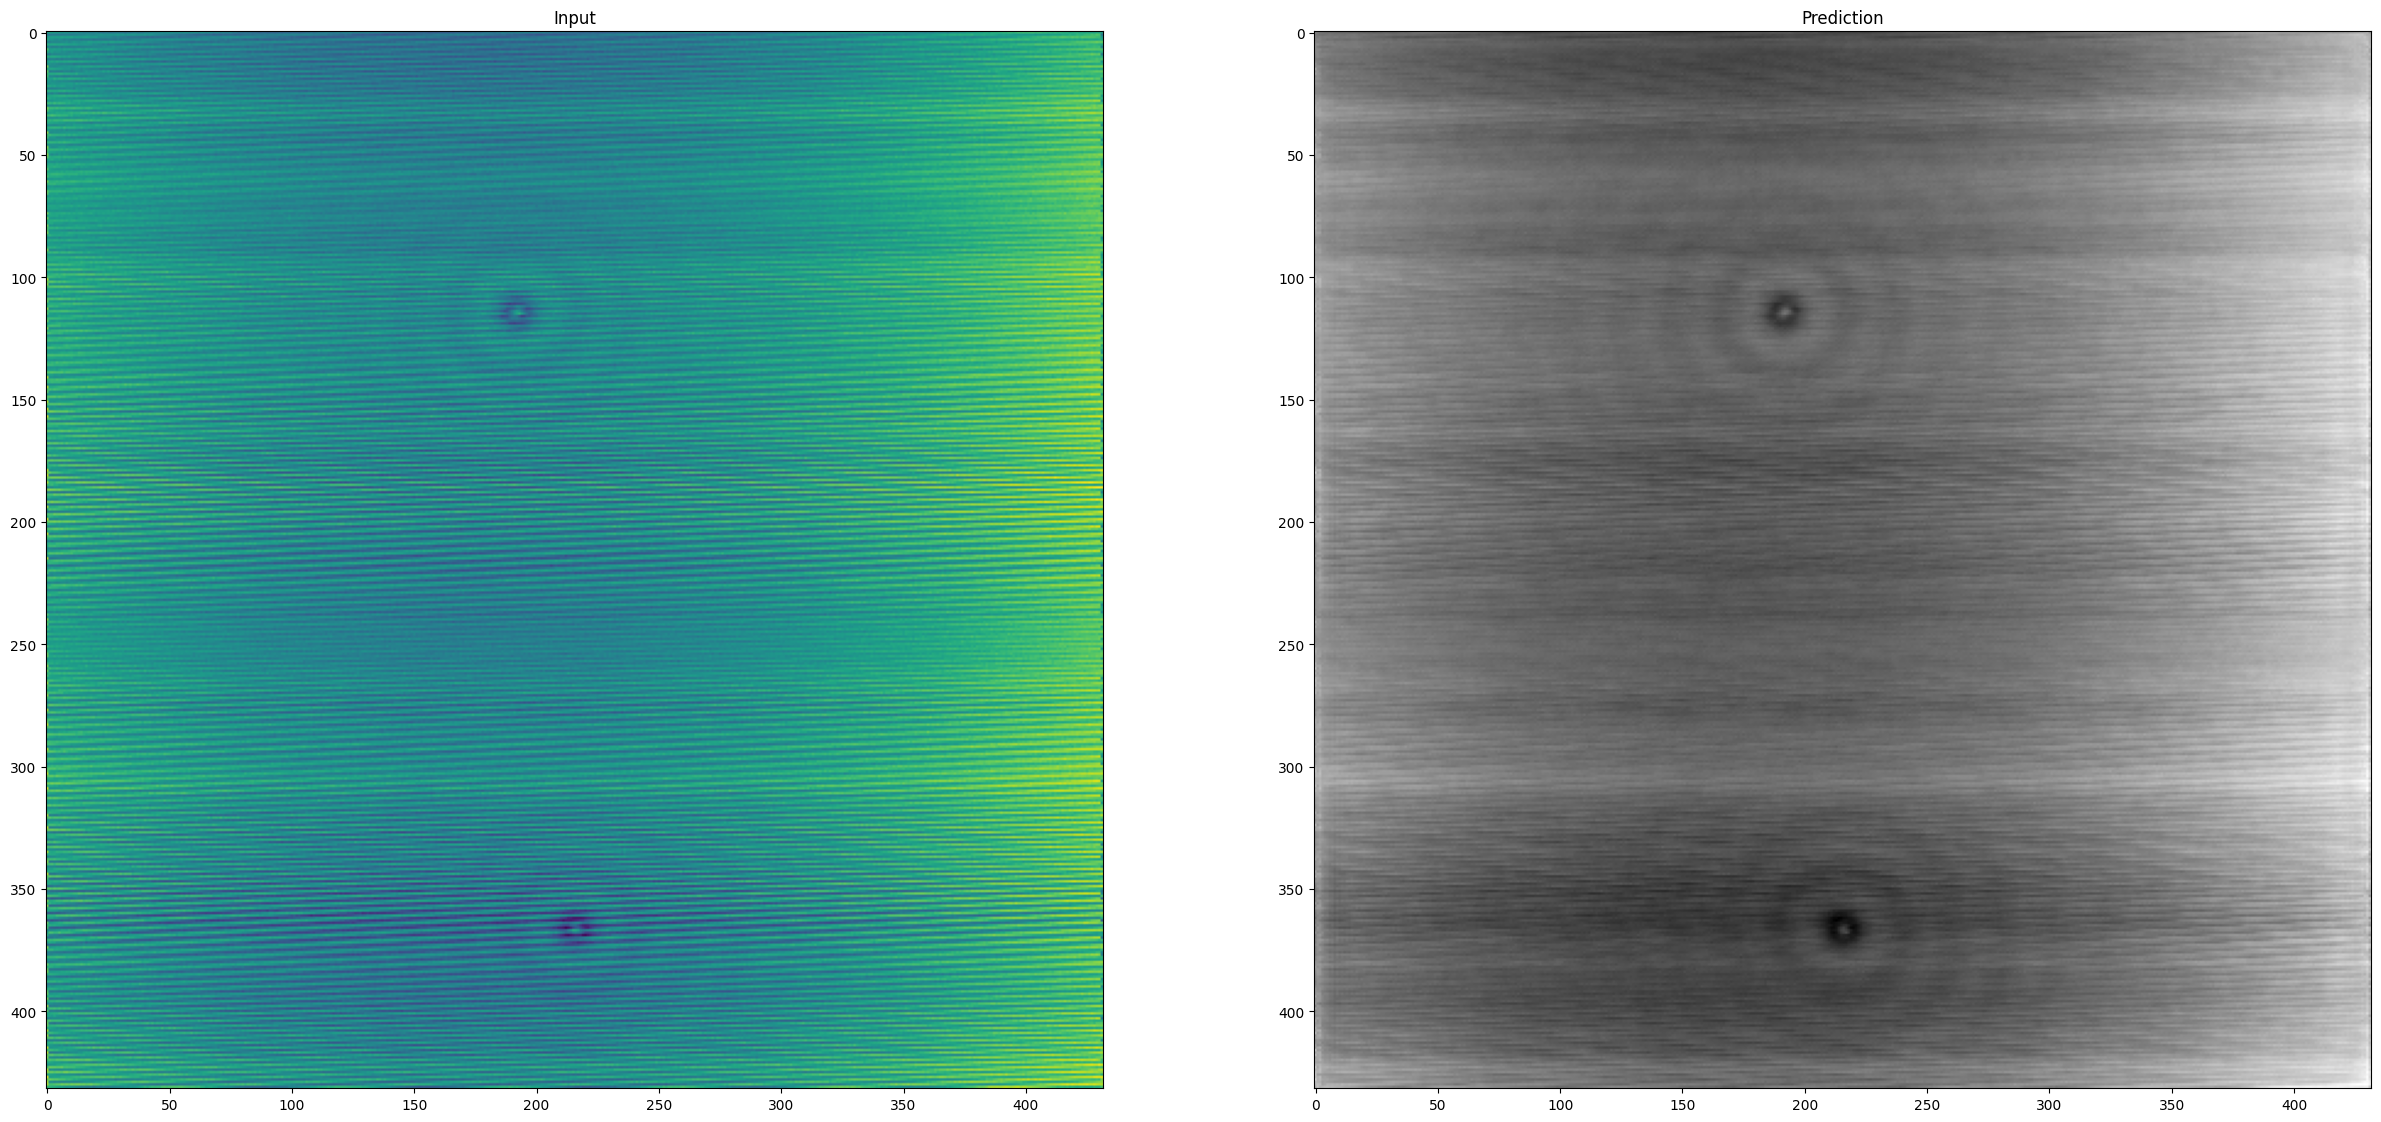

In [67]:
# Let's look at the results.
plt.figure(figsize=(30,30))

# We show the noisy input...
plt.subplot(1,2,1)
plt.imshow( img )
plt.title('Input');

# and the result.
plt.subplot(1,2,2)
plt.imshow( pred, cmap='gray')
plt.title('Prediction');


## Save Results

In [60]:
plt.imsave('cropped_copper/Cu(111)_0122.sxm_Z_sub_forward_01_N2V_denoised.png', pred, cmap="gray")